In [1]:
# Standard imports
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cpu
PyTorch version: 2.9.0


In [2]:
# Load training dataset
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

# Calculating the mean and std
data = train_dataset.data.float()
calculated_mean = data.mean() / 255
calculated_std = data.std()

#Define the transformation for both train and test
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((calculated_mean,), (calculated_std,))
])

#Applying transform on train
train_dataset.transforms = transform

# Load test dataset and applying the transform
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

print(f'Training samples: {len(train_dataset)}')
print(f'Test samples: {len(test_dataset)}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 26.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 819kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 7.09MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.87MB/s]

Training samples: 60000
Test samples: 10000


In [3]:
# Create DataLoaders
# DataLoader handles batching, shuffling, and parallel data loading
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,  # Shuffle training data for better learning
    num_workers=2  # Parallel data loading (set to 0 if on Windows)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,  # No need to shuffle test data
    num_workers=2
)

print(f'Number of training batches: {len(train_loader)}')
print(f'Number of test batches: {len(test_loader)}')


Number of training batches: 938
Number of test batches: 157


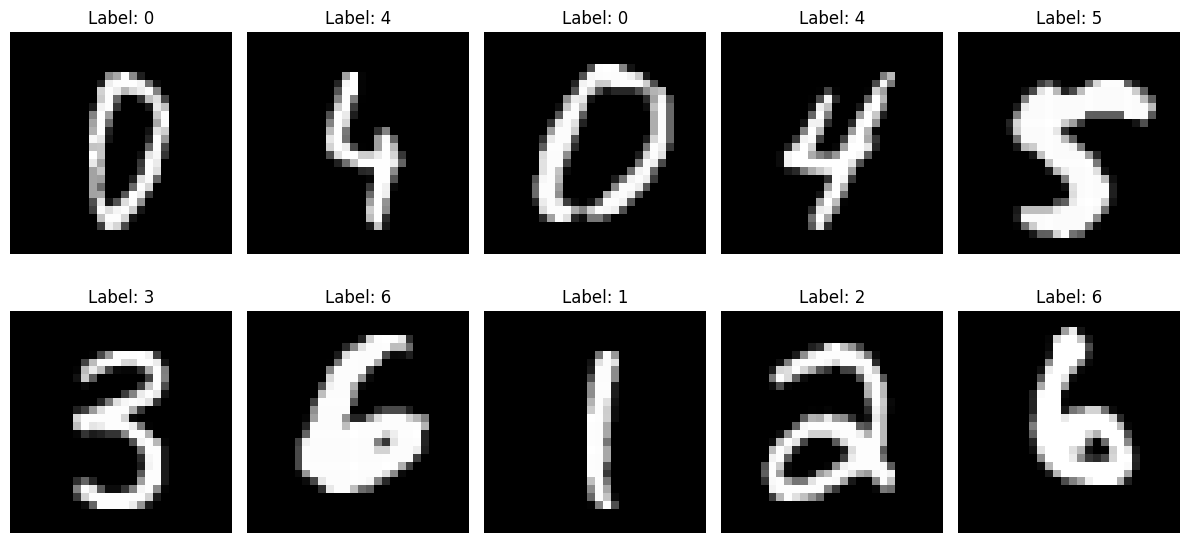

Image shape: torch.Size([1, 28, 28])
Label: 0


In [4]:
# Get a batch of data
data_iter = iter(train_loader)
images, labels = next(data_iter)

# Visualize some samples
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i in range(10):
    row, col = i // 5, i % 5
    # Denormalize for visualization
    img = images[i].squeeze()
    img = img * 0.3081 + 0.1307  # Reverse normalization
    axes[row, col].imshow(img, cmap='gray')
    axes[row, col].set_title(f'Label: {labels[i].item()}')
    axes[row, col].axis('off')
plt.tight_layout()
plt.show()

print(f'Image shape: {images[0].shape}')  # Should be [1, 28, 28] for MNIST
print(f'Label: {labels[0].item()}')


In [5]:
class SimpleNetwork(nn.Module):
  def __init__(self):
    super(SimpleNetwork, self).__init__()
    # MNIST images are 28x28
    self.fc1 = nn.Linear(28 * 28, 128)

    self.fc2 = nn.Linear(128, 64)

    self.fc3 = nn.Linear(64, 10)

  def forward(self, x):

    x = x.view(-1, 28 * 28)

    x = F.relu(self.fc1(x))

    x = F.relu(self.fc2(x))

    x = self.fc3(x)

    return x

In [6]:
model = SimpleNetwork().to(device)
print(model)

SimpleNetwork(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


In [7]:
# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Total parameters: 109,386
Trainable parameters: 109,386


In [8]:
# Loss function: CrossEntropyLoss (combines LogSoftmax and NLLLoss)
# For multi-class classification with 10 classes
criterion = nn.CrossEntropyLoss()

# Optimizer: Stochastic Gradient Descent
# lr: learning rate (how big steps to take)
# momentum: helps accelerate gradients in the right direction
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

print(f'Loss function: {criterion}')
print(f'Optimizer: {optimizer}')

Loss function: CrossEntropyLoss()
Optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
)


In [9]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    """
    Train the model for one epoch
    """
    # Set model to training mode
    # This enables dropout, batch norm updates, etc.
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    # Iterate over batches
    for batch_idx, (images, labels) in enumerate(train_loader):
        # Move data to device (GPU if available)
        images = images.to(device)
        labels = labels.to(device)

        # Zero gradients (important!)
        # PyTorch accumulates gradients, so we need to zero them before each backward pass
        optimizer.zero_grad()

        # Forward pass: compute predictions
        outputs = model(images)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backward pass: compute gradients
        loss.backward()

        # Update weights: optimizer step
        optimizer.step()

        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)  # Get predicted class
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Print progress every 100 batches
        if (batch_idx + 1) % 100 == 0:
            print(f'Batch [{batch_idx + 1}/{len(train_loader)}], '
                  f'Loss: {loss.item():.4f}, '
                  f'Accuracy: {100 * correct / total:.2f}%')

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [11]:
def evaluate(model, test_loader, criterion, device):
    """
    Evaluate the model on test data
    """
    # Set model to evaluation mode
    # This disables dropout, batch norm uses running stats, etc.
    model.eval()

    test_loss = 0.0
    correct = 0
    total = 0

    # Disable gradient computation during evaluation (saves memory and computation)
    with torch.no_grad():
        for images, labels in test_loader:
            # Move data to device
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Compute loss
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            # Get predictions
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Calculate average loss and accuracy
    avg_loss = test_loss / len(test_loader)
    accuracy = 100 * correct / total

    return avg_loss, accuracy

In [12]:
# Training parameters
num_epochs = 2

# Lists to store training history
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

print('Starting training...')
print('=' * 50)

for epoch in range(num_epochs):
    print(f'\nEpoch [{epoch + 1}/{num_epochs}]')
    print('-' * 50)

    # Train for one epoch
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    # Evaluate on test set
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    # Store metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    # Print epoch summary
    print(f'\nEpoch [{epoch + 1}/{num_epochs}] Summary:')
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'  Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')

print('\n' + '=' * 50)
print('Training completed!')


Starting training...

Epoch [1/2]
--------------------------------------------------
Batch [100/938], Loss: 0.1094, Accuracy: 92.66%
Batch [200/938], Loss: 0.2742, Accuracy: 93.35%
Batch [300/938], Loss: 0.3177, Accuracy: 93.56%
Batch [400/938], Loss: 0.2980, Accuracy: 93.73%
Batch [500/938], Loss: 0.1574, Accuracy: 93.94%
Batch [600/938], Loss: 0.2497, Accuracy: 94.09%
Batch [700/938], Loss: 0.2347, Accuracy: 94.19%
Batch [800/938], Loss: 0.2432, Accuracy: 94.28%
Batch [900/938], Loss: 0.1727, Accuracy: 94.38%

Epoch [1/2] Summary:
  Train Loss: 0.1890, Train Acc: 94.43%
  Test Loss: 2.4287, Test Acc: 8.92%

Epoch [2/2]
--------------------------------------------------
Batch [100/938], Loss: 0.2514, Accuracy: 96.44%
Batch [200/938], Loss: 0.0395, Accuracy: 96.10%
Batch [300/938], Loss: 0.1281, Accuracy: 95.97%
Batch [400/938], Loss: 0.0489, Accuracy: 96.04%
Batch [500/938], Loss: 0.1352, Accuracy: 96.11%
Batch [600/938], Loss: 0.0747, Accuracy: 96.16%
Batch [700/938], Loss: 0.0981, A

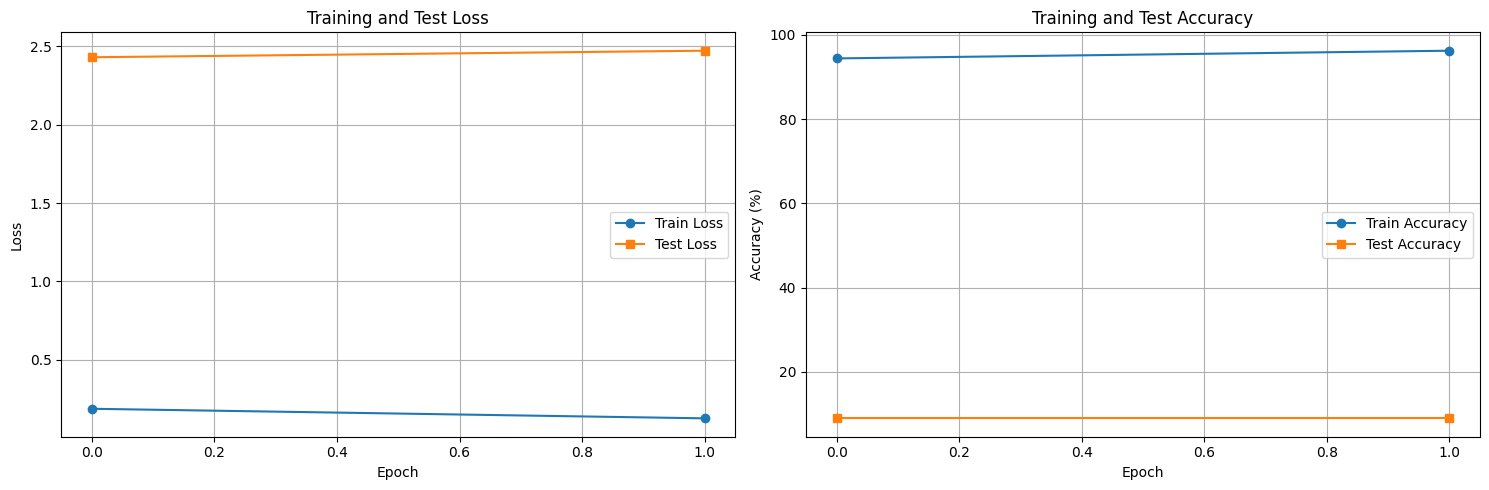

In [13]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot loss
ax1.plot(train_losses, label='Train Loss', marker='o')
ax1.plot(test_losses, label='Test Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Test Loss')
ax1.legend()
ax1.grid(True)

# Plot accuracy
ax2.plot(train_accuracies, label='Train Accuracy', marker='o')
ax2.plot(test_accuracies, label='Test Accuracy', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Test Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [14]:
# Get a batch of test images
data_iter = iter(test_loader)

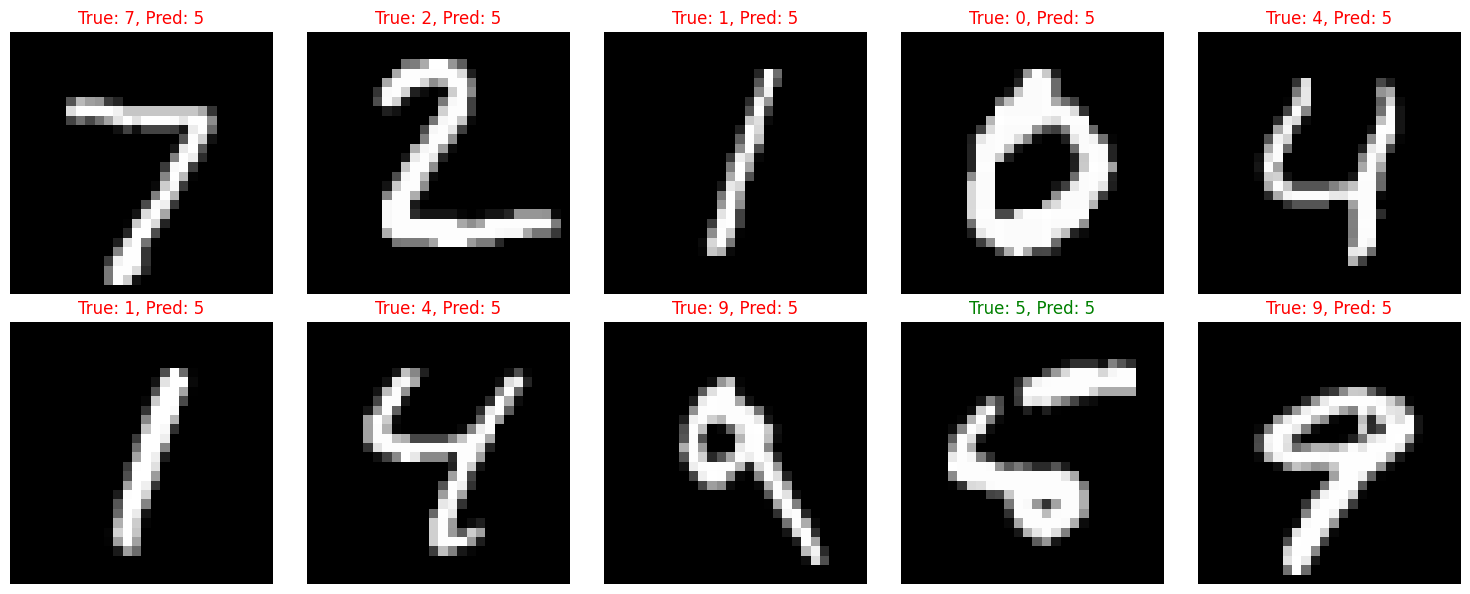

Accuracy on this batch: 10.94%


In [15]:
try:
    images, labels = next(data_iter)
except StopIteration:
    data_iter = iter(test_loader) # Reset if we reach the end
    images, labels = next(data_iter)

images = images.to(device)

# Make predictions
model.eval()
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

# Visualize predictions
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    row, col = i // 5, i % 5
    # Denormalize for visualization
    img = images[i].cpu().squeeze()
    img = img * 0.3081 + 0.1307

    axes[row, col].imshow(img, cmap='gray')

    # Color: green if correct, red if wrong
    color = 'green' if predicted[i] == labels[i] else 'red'
    axes[row, col].set_title(f'True: {labels[i].item()}, Pred: {predicted[i].item()}',
                            color=color, fontsize=12)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# Print accuracy for this batch
correct_batch = (predicted == labels.to(device)).sum().item()
print(f'Accuracy on this batch: {100 * correct_batch / len(labels):.2f}%')
